In [1]:
from pathlib import Path
from copy import deepcopy
import random

from ipywidgets import interact, fixed, widgets
import pandas as pd
from rdkit import Chem, Geometry
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS

In [2]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

In [3]:
sdf = str(HERE / "data/molecule_set_cluster6.sdf")
supplier = Chem.ForwardSDMolSupplier(sdf)
mols = list(supplier)

print(f"Set with {len(mols)} molecules loaded.")
# NBVAL_CHECK_OUTPUT

Set with 14 molecules loaded.


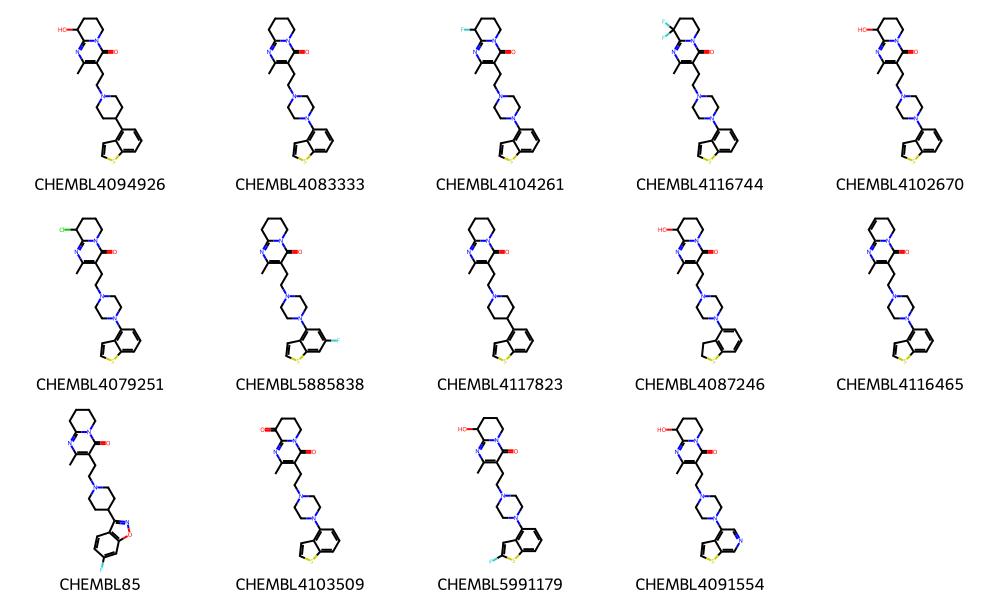

In [4]:
# Show all molecules in the cluster
num_mols = len(mols)
legends = [mol.GetProp("_Name") for mol in mols]
Draw.MolsToGridImage(mols[:num_mols], legends=legends[:num_mols], molsPerRow=5)

In [5]:
mcs1 = rdFMCS.FindMCS(mols)
print(f"MCS1 contains {mcs1.numAtoms} atoms and {mcs1.numBonds} bonds.")
print("MCS SMARTS string:", mcs1.smartsString)
# NBVAL_CHECK_OUTPUT

MCS1 contains 19 atoms and 19 bonds.
MCS SMARTS string: [#6]-[#6]1:[#7]:[#6](:[#7](:[#6](:[#6]:1-[#6]-[#6]-[#7](-[#6]-[#6])-[#6]-[#6])=[#8])-[#6]-[#6]-[#6])-[#6]


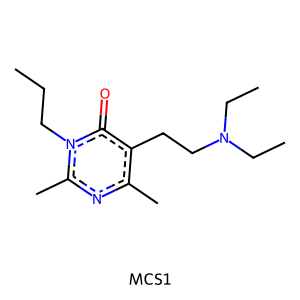

In [6]:
# Draw substructure from Smarts
m1 = Chem.MolFromSmarts(mcs1.smartsString)
Draw.MolToImage(m1, legend="MCS1")

In [7]:
def highlight_molecules(molecules, mcs, number, label=True, same_orientation=True, **kwargs):
    """Highlight the MCS in our query molecules"""
    molecules = deepcopy(molecules)
    # convert MCS to molecule
    pattern = Chem.MolFromSmarts(mcs.smartsString)
    # find the matching atoms in each molecule
    matching = [molecule.GetSubstructMatch(pattern) for molecule in molecules[:number]]

    legends = None
    if label is True:
        legends = [x.GetProp("_Name") for x in molecules]

    # Align by matched substructure so they are depicted in the same orientation
    # Adapted from: https://gist.github.com/greglandrum/82d9a86acb3b00d3bb1df502779a5810
    if same_orientation:
        mol, match = molecules[0], matching[0]
        AllChem.Compute2DCoords(mol)
        coords = [mol.GetConformer().GetAtomPosition(x) for x in match]
        coords2D = [Geometry.Point2D(pt.x, pt.y) for pt in coords]
        for mol, match in zip(molecules[1:number], matching[1:number]):
            if not match:
                continue
            coord_dict = {match[i]: coord for i, coord in enumerate(coords2D)}
            AllChem.Compute2DCoords(mol, coordMap=coord_dict)

    return Draw.MolsToGridImage(
        molecules[:number],
        legends=legends,
        molsPerRow=5,
        highlightAtomLists=matching[:number],
        subImgSize=(200, 200),
        **kwargs,
    )

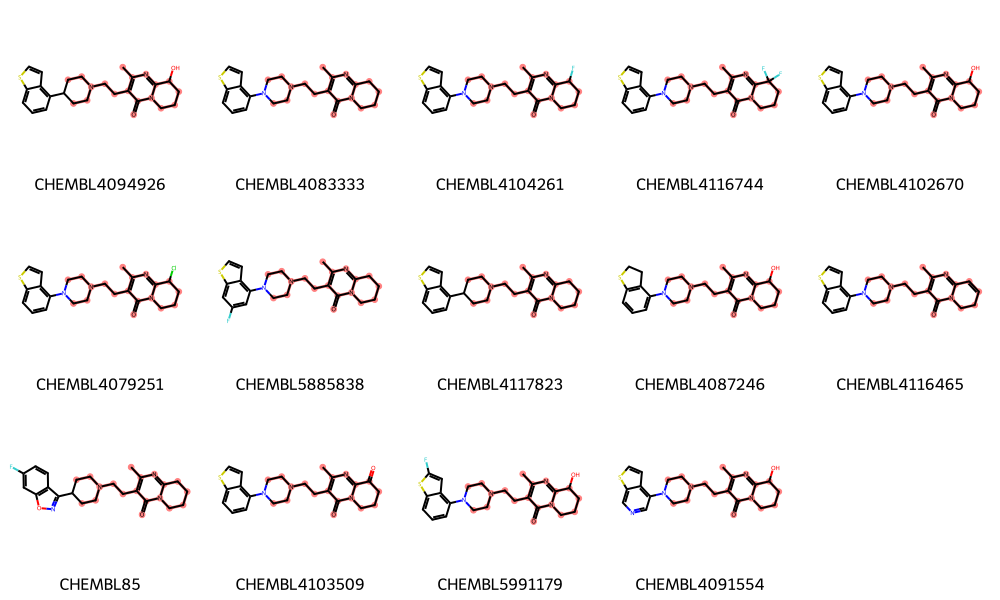

In [8]:
highlight_molecules(mols, mcs1, len(mols))

In [9]:
img = highlight_molecules(mols, mcs1, len(mols), useSVG=True)

# Get SVG data
molsvg = img.data

# Set background to transparent & Enlarge size of label
molsvg = molsvg.replace("opacity:1.0", "opacity:0.0").replace("12px", "20px")

# Save altered SVG data to file
with open(DATA / "mcs_cluster6.svg", "w") as f:
    f.write(molsvg)

In [10]:
mcs2 = rdFMCS.FindMCS(mols, threshold=0.8)
print(f"MCS2 contains {mcs2.numAtoms} atoms and {mcs2.numBonds} bonds.")
print("SMARTS string:", mcs2.smartsString)
# NBVAL_CHECK_OUTPUT

MCS2 contains 19 atoms and 20 bonds.
SMARTS string: [#6]-[#6]1:[#7]:[#6]2:[#7](:[#6](:[#6]:1-[#6]-[#6]-[#7](-[#6]-[#6])-[#6]-[#6])=[#8])-[#6]-[#6]-[#6]-[#6]-2


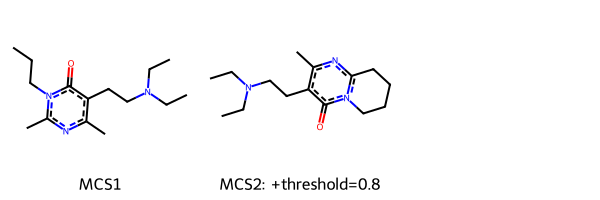

In [11]:
# Draw substructure
m2 = Chem.MolFromSmarts(mcs2.smartsString)
Draw.MolsToGridImage([m1, m2], legends=["MCS1", "MCS2: +threshold=0.8"])

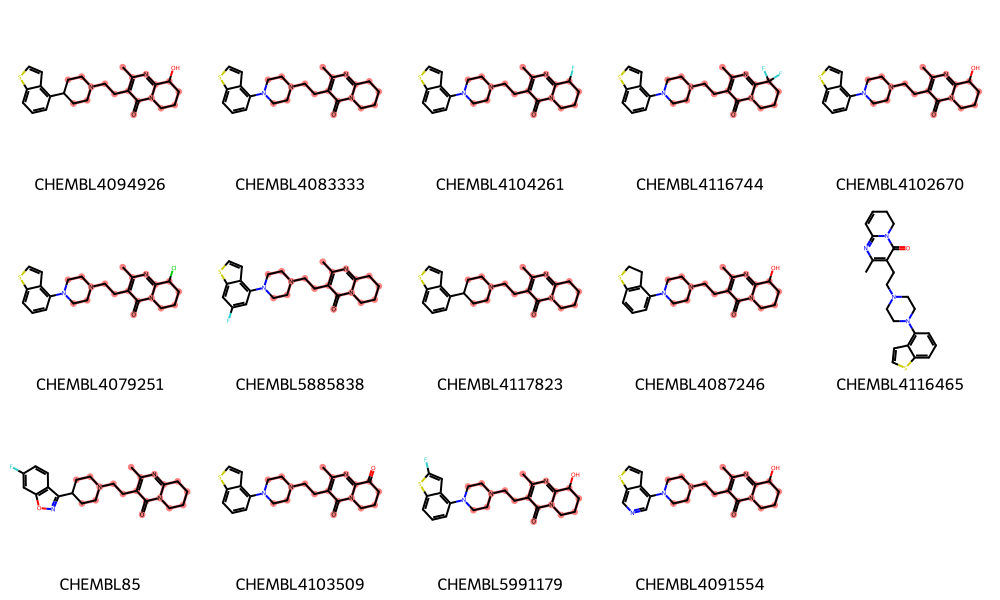

In [12]:
highlight_molecules(mols, mcs2, len(mols))

In [13]:
mcs3 = rdFMCS.FindMCS(mols, threshold=0.8, ringMatchesRingOnly=True)
print(f"MCS3 contains {mcs3.numAtoms} atoms and {mcs3.numBonds} bonds.")
print("SMARTS string:", mcs3.smartsString)
# NBVAL_CHECK_OUTPUT

MCS3 contains 19 atoms and 20 bonds.
SMARTS string: [#6&!R]-&!@[#6]1:&@[#7]:&@[#6]2:&@[#7](:&@[#6](:&@[#6]:&@1-&!@[#6&!R]-&!@[#6&!R]-&!@[#7&R](-&@[#6&R]-&@[#6&R])-&@[#6&R]-&@[#6&R])=&!@[#8&!R])-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@2


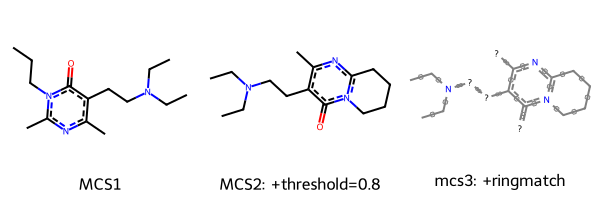

In [14]:
# Draw substructure
m3 = Chem.MolFromSmarts(mcs3.smartsString)
Draw.MolsToGridImage([m1, m2, m3], legends=["MCS1", "MCS2: +threshold=0.8", "mcs3: +ringmatch"])

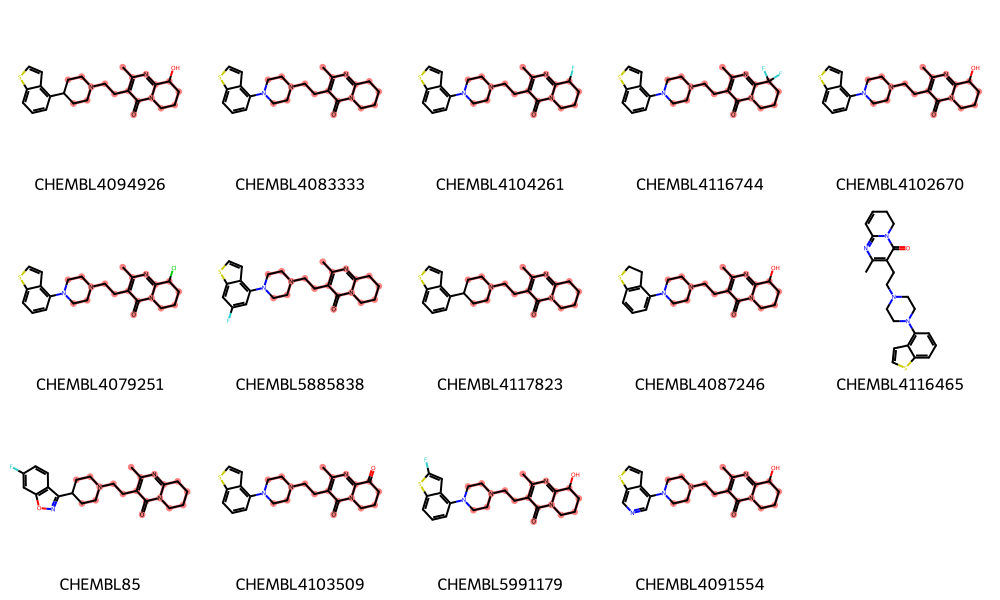

In [15]:
highlight_molecules(mols, mcs3, len(mols))

In [16]:
# Read full D2 data
mol_df = pd.read_csv(HERE.parent / "data" / "DopamineD2_compounds.csv", index_col=0)
print("Total number of compounds:", mol_df.shape[0])

# Only keep molecules with pIC50 > 8 (IC50 < 10 nM)
mol_df = mol_df[mol_df.pIC50 > 8]
print("Number of compounds with pIC50 > 8:", mol_df.shape[0])

Total number of compounds: 435
Number of compounds with pIC50 > 8: 66


In [17]:
mols_diverse = []
# Note: discarded variables we do not care about are usually referred to with a single underscore
for _, row in mol_df.iterrows():
    m = Chem.MolFromSmiles(row.smiles)
    m.SetProp("_Name", str(row.name))
    mols_diverse.append(m)

In [18]:
# Fix the random seed for deterministic results
random.seed(42)
mols_diverse_sample = random.sample(mols_diverse, 50)

In [19]:
threshold_diverse = 0.7
mcs1 = rdFMCS.FindMCS(mols_diverse_sample)
print("SMARTS string1:", mcs1.smartsString)
mcs2 = rdFMCS.FindMCS(mols_diverse_sample, threshold=threshold_diverse)
print("SMARTS string2:", mcs2.smartsString)
mcs3 = rdFMCS.FindMCS(mols_diverse_sample, ringMatchesRingOnly=True, threshold=threshold_diverse)
print("SMARTS string3:", mcs3.smartsString)
# NBVAL_CHECK_OUTPUT

SMARTS string1: [#6]-,:[#6]-,:[#7]-,:[#6]-,:[#6]:,-[#6]:,-[#6]:,-[#6]:,-[#6]
SMARTS string2: [#6]-[#6]-[#7](-[#6]-,:[#6]-,:[#6])-[#6]-[#6]-[#7]-[#6]-,:[#6]:,-[#6]:,-[#6]:,-[#6]:,-[#6]
SMARTS string3: [#6]1-,:;@[#6](:,-;@[#6&R]:,-;@[#6&R]):&@[#6]:&@[#6]-,:;@[#6]-,:;@[#6]-,:;@1


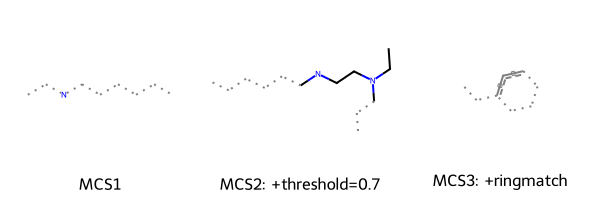

In [20]:
# Draw substructures
m1 = Chem.MolFromSmarts(mcs1.smartsString)
m2 = Chem.MolFromSmarts(mcs2.smartsString)
m3 = Chem.MolFromSmarts(mcs3.smartsString)

Draw.MolsToGridImage(
    [m1, m2, m3],
    legends=[
        "MCS1",
        f"MCS2: +threshold={threshold_diverse}",
        "MCS3: +ringmatch",
    ],
)

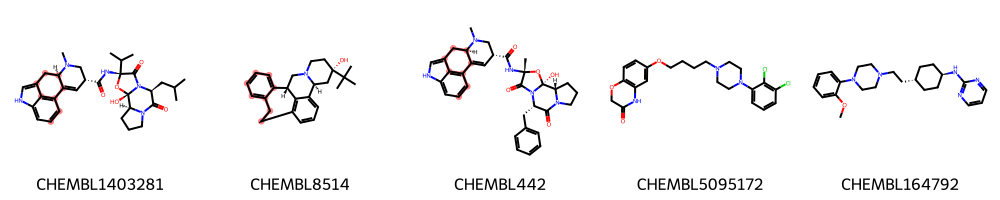

In [21]:
highlight_molecules(mols_diverse_sample, mcs3, 5)

In [22]:
def render_mcs(molecules, percentage):
    """Interactive widget helper. `molecules` must be wrapped in `ipywidgets.fixed()`,
    while `percentage` will be determined by an IntSlider widget."""
    tmcs = rdFMCS.FindMCS(molecules, threshold=percentage / 100.0)
    if tmcs is None:
        print("No MCS found")
        return None

    m = Chem.MolFromSmarts(tmcs.smartsString)
    print(tmcs.smartsString)
    return m

In [23]:
# Note that the slider may take a few seconds to react
interact(
    render_mcs,
    molecules=fixed(mols_diverse_sample),
    percentage=widgets.IntSlider(min=0, max=100, step=10, value=70),
);

interactive(children=(IntSlider(value=70, description='percentage', step=10), Output()), _dom_classes=('widget…

## High vs low pIC50: do potent compounds have different scaffolds?
- **high**: pIC50 > 8 (IC50 < 10 nM)
- **low**: pIC50 < 6 (IC50 > 1 µM)

In [24]:
from rdkit.Chem.Scaffolds import MurckoScaffold

# Reload the full D2 data (mol_df above only holds the pIC50 > 8 compounds)
all_df = pd.read_csv(HERE.parent / "data" / "DopamineD2_compounds.csv", index_col=0)
all_df["mol"] = all_df.smiles.apply(Chem.MolFromSmiles)

# Assign activity groups
all_df["group"] = "mid"
all_df.loc[all_df.pIC50 > 8, "group"] = "high"
all_df.loc[all_df.pIC50 < 6, "group"] = "low"
print(all_df.group.value_counts())

group
mid     246
low     123
high     66
Name: count, dtype: int64


In [25]:
# Murcko scaffold = ring systems + the linkers between them (side chains removed)
all_df["scaffold"] = all_df.mol.apply(lambda m: Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(m)))
print("Number of unique scaffolds:", all_df.scaffold.nunique())

# Count how often each scaffold occurs per activity group
scaffold_counts = pd.crosstab(all_df.scaffold, all_df.group)[["high", "mid", "low"]]
scaffold_counts["total"] = scaffold_counts.sum(axis=1)
scaffold_counts["mean_pIC50"] = all_df.groupby("scaffold").pIC50.mean().round(2)
scaffold_counts.sort_values("total", ascending=False).head(15)

Number of unique scaffolds: 271


group,high,mid,low,total,mean_pIC50
scaffold,,,,,
c1ccc([C@H]2C[C@@H]2CN2CCN(c3ccccc3)CC2)cc1,5,18,0,23,7.41
O=C(CCCN1CCN(c2ccccc2)CC1)NCc1nc2ccccc2c(=O)n1-c1ccccc1,0,2,6,8,5.69
O=c1c(CCN2CCN(c3cccc4sccc34)CC2)cnc2n1CCCC2,5,2,0,7,8.11
c1ccc2c(c1)N=C(N1CCNCC1)c1ccccc1N2,0,5,2,7,6.54
O=C1Cc2cc(CCN3CCN(c4cccc5sccc45)CC3)ccc2N1,2,4,0,6,7.71
c1ccc(-c2cccc(CN3CCN(c4ncccn4)CC3)c2)cc1,0,6,0,6,6.84
c1ccc2c(c1)C[C@H]1NCCc3cccc-2c31,0,4,2,6,6.66
c1ccc2c(c1)C[C@H]1c3ccccc3CCN1C2,0,4,2,6,6.23
O=C1COc2ccc(CCN3CCN(c4cccc5sccc45)CC3)cc2N1,0,5,0,5,7.34


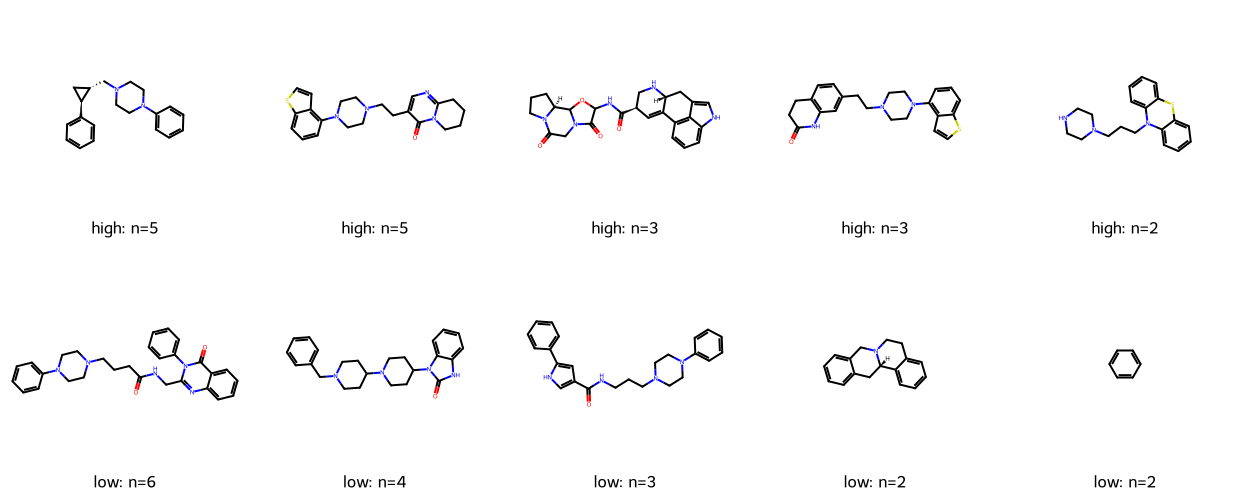

In [26]:
def top_scaffolds(group, n=5):
    """Return the n most frequent scaffolds of an activity group as molecules + legends."""
    counts = all_df[all_df.group == group].scaffold.value_counts().head(n)
    scaffold_mols = [Chem.MolFromSmiles(smiles) for smiles in counts.index]
    legends = [f"{group}: n={count}" for count in counts]
    return scaffold_mols, legends


# Top row: most frequent scaffolds in the high group, bottom row: in the low group
high_mols, high_legends = top_scaffolds("high")
low_mols, low_legends = top_scaffolds("low")
Draw.MolsToGridImage(
    high_mols + low_mols, legends=high_legends + low_legends, molsPerRow=5, subImgSize=(250, 250)
)

high (66 compounds): [#6&!R]-&!@[#6&!R]-&!@[#7&R](-&@[#6&R]-&@[#6&R])-&@[#6&R]-&@[#6&R]
low (123 compounds): [#6]1:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@1


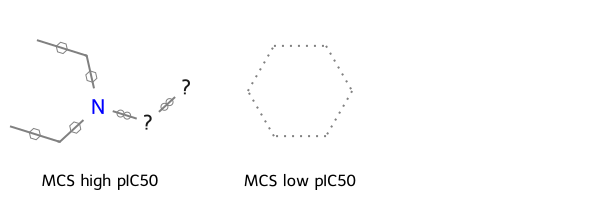

In [27]:
# MCS of each activity group (same settings as MCS3 of the diverse set)
mcs_by_group = {}
for group in ["high", "low"]:
    group_mols = list(all_df[all_df.group == group].mol)
    mcs_by_group[group] = rdFMCS.FindMCS(
        group_mols, threshold=0.7, ringMatchesRingOnly=True, timeout=60
    )
    print(f"{group} ({len(group_mols)} compounds): {mcs_by_group[group].smartsString}")

Draw.MolsToGridImage(
    [Chem.MolFromSmarts(mcs.smartsString) for mcs in mcs_by_group.values()],
    legends=[f"MCS {group} pIC50" for group in mcs_by_group],
)

In [28]:
# Percentage of compounds in each group that contain a motif
motifs = {
    "basic aliphatic amine": "[NX3;!$(N-C=[O,S,N]);!$(N-S(=O)=O);!$(N-a);!$(N=*)]",
    "aryl-piperazine": "c-N1CCN(-[CX4])CC1",
    "4-aryl-piperidine": "c-C1CCN(-[CX4])CC1",
    "ethyl linker on ring N": "[NX3;R;!$(N-a);!$(N-C=O)]-[CH2]-[CH2]",
    "benzothiophene": "c1ccc2sccc2c1",
    "cluster 6 head (pyridopyrimidinone)": "Cc1nc2n(c(=O)c1CC)CCCC2",
    "amide": "C(=O)N",
}
motif_hits = pd.DataFrame(
    {
        name: all_df.mol.apply(lambda m, pattern=Chem.MolFromSmarts(smarts): m.HasSubstructMatch(pattern))
        for name, smarts in motifs.items()
    }
)
motif_percentages = (motif_hits.groupby(all_df.group).mean() * 100).round(0).T[["high", "mid", "low"]]
motif_percentages.columns = ["% high", "% mid", "% low"]
motif_percentages

,% high,% mid,% low
basic aliphatic amine,97.0,100.0,89.0
aryl-piperazine,62.0,59.0,15.0
4-aryl-piperidine,3.0,6.0,5.0
ethyl linker on ring N,86.0,94.0,76.0
benzothiophene,44.0,24.0,2.0
cluster 6 head (pyridopyrimidinone),8.0,3.0,0.0
amide,53.0,42.0,59.0


### Within cluster 6: which changes affect pIC50?

In [29]:
# Substituent on position 9 of the saturated ring of the pyridopyrimidinone head
position9_patterns = {
    "OH": "[#7]:c(:[#7])-[C;R][OX2H1]",
    "F2": "[#7]:c(:[#7])-[C;R](F)F",
    "F": "[#7]:c(:[#7])-[C;R]F",
    "Cl": "[#7]:c(:[#7])-[C;R]Cl",
    "=O": "[#7]:c(:[#7])-[C;R]=O",
    "C=C": "[#7]:c(:[#7])-[C;R]=[C;R]",
}
position9_patterns = {name: Chem.MolFromSmarts(smarts) for name, smarts in position9_patterns.items()}
# Linker -CH2- attached to the amine ring, whose para atom carries the aryl tail
amine_ring_pattern = Chem.MolFromSmarts("[#6]-[#7;R]1-[#6]-[#6]-[#6,#7](-!@[a])-[#6]-[#6]-1")

cluster_rows = []
for mol in mols:
    name = mol.GetProp("_Name")
    position9 = next((sub for sub, pattern in position9_patterns.items() if mol.HasSubstructMatch(pattern)), "H")

    match = mol.GetSubstructMatch(amine_ring_pattern)
    ring_atom, aryl_atom = match[4], match[5]
    amine_ring = "piperazine" if mol.GetAtomWithIdx(ring_atom).GetSymbol() == "N" else "piperidine"

    # Cut the bond between amine ring and aryl tail; the tail is the fragment containing the aryl atom
    bond = mol.GetBondBetweenAtoms(ring_atom, aryl_atom).GetIdx()
    fragments = Chem.GetMolFrags(Chem.FragmentOnBonds(mol, [bond], addDummies=False), asMols=False)
    tail_atoms = next(fragment for fragment in fragments if aryl_atom in fragment)
    tail = Chem.MolFragmentToSmiles(mol, atomsToUse=tail_atoms)

    cluster_rows.append(
        {"name": name, "pIC50": all_df.loc[name, "pIC50"], "position 9": position9, "amine ring": amine_ring, "aryl tail": tail}
    )

cluster_df = pd.DataFrame(cluster_rows).sort_values("pIC50", ascending=False).reset_index(drop=True)
cluster_df.round(2)

,name,pIC50,position 9,amine ring,aryl tail
0,CHEMBL4083333,8.58,H,piperazine,c1ccc2sccc2c1
1,CHEMBL4104261,8.48,F,piperazine,c1ccc2sccc2c1
2,CHEMBL4116744,8.45,F2,piperazine,c1ccc2sccc2c1
3,CHEMBL4102670,8.27,OH,piperazine,c1ccc2sccc2c1
4,CHEMBL4079251,8.26,Cl,piperazine,c1ccc2sccc2c1
5,CHEMBL5885838,7.98,H,piperazine,Fc1ccc2ccsc2c1
6,CHEMBL4117823,7.98,H,piperidine,c1ccc2sccc2c1
7,CHEMBL4087246,7.93,OH,piperazine,c1ccc2c(c1)CCS2
8,CHEMBL4116465,7.78,C=C,piperazine,c1ccc2sccc2c1
9,CHEMBL85,7.70,H,piperidine,Fc1ccc2cnoc2c1


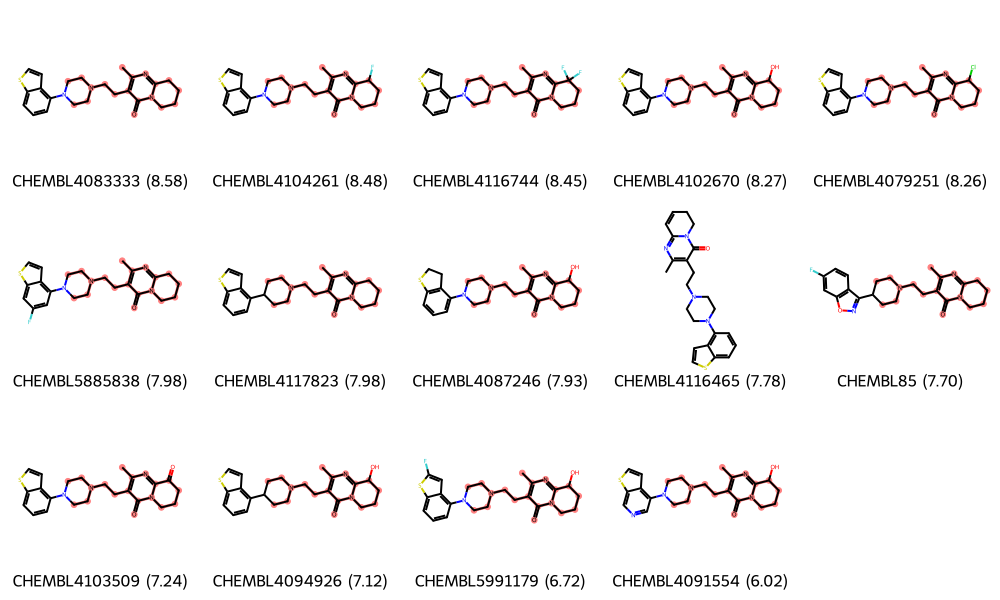

In [30]:
# Cluster 6 sorted by pIC50, highlighted with the cluster scaffold (MCS3 of the cluster)
mcs_cluster = rdFMCS.FindMCS(mols, threshold=0.8, ringMatchesRingOnly=True)

mols_by_name = {mol.GetProp("_Name"): mol for mol in mols}
mols_sorted = []
for _, row in cluster_df.iterrows():
    mol = Chem.Mol(mols_by_name[row["name"]])
    mol.SetProp("_Name", f"{row['name']} ({row['pIC50']:.2f})")
    mols_sorted.append(mol)

highlight_molecules(mols_sorted, mcs_cluster, len(mols_sorted))